In [25]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from collections import Counter

In [26]:
df = pd.read_csv("eye_tracking_dataset.csv")

# lihat sekilas
print(df.head())
print(df["label"].value_counts())

   avg_velocity  max_velocity  std_velocity  total_distance  fixation_ratio  \
0      0.490741      2.591705      0.718205        5.392815        0.066667   
1      0.451843      2.233097      0.664036        4.890438        0.066667   
2      0.220778      0.669153      0.201033        2.413689        0.100000   
3      0.338463      1.671495      0.422953        3.687045        0.000000   
4      0.361596      2.403731      0.588044        3.899846        0.033333   

   unique_area_count                                       file   label  
0                  7  47012b2f-426a-41f7-a6cb-1908b8881cdc.json  tinggi  
1                  4  47012b2f-426a-41f7-a6cb-1908b8881cdc.json  tinggi  
2                  5  47012b2f-426a-41f7-a6cb-1908b8881cdc.json  tinggi  
3                  5  47012b2f-426a-41f7-a6cb-1908b8881cdc.json  tinggi  
4                  5  47012b2f-426a-41f7-a6cb-1908b8881cdc.json  tinggi  
label
tinggi    56
sedang    41
Name: count, dtype: int64


In [27]:
X = df.drop(columns=["file", "label"])
y = df["label"]

le = LabelEncoder()
y = le.fit_transform(y)

print(le.classes_)  # untuk cek mapping label

['sedang' 'tinggi']


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# gss = GroupShuffleSplit(test_size=0.3, random_state=42)
# groups = df["file"]

# for train_idx, test_idx in gss.split(X, y, groups):
#     X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
#     y_train, y_test = y[train_idx], y[test_idx]

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [29]:
model = SVC(
    kernel="rbf",   # bisa coba: linear / poly / rbf
    C=.8,
    gamma="scale",
    class_weight="balanced",
    probability=True
)

In [30]:
model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.8
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [31]:
y_pred = model.predict(X_test)

In [32]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.85
              precision    recall  f1-score   support

           0       1.00      0.62      0.77         8
           1       0.80      1.00      0.89        12

    accuracy                           0.85        20
   macro avg       0.90      0.81      0.83        20
weighted avg       0.88      0.85      0.84        20



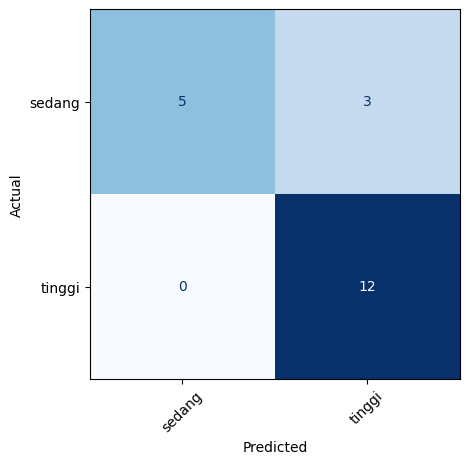

In [33]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

disp.plot(cmap=plt.cm.Blues, values_format="d", xticks_rotation=45, colorbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [34]:
# Simpan model Support Vector Machine
joblib.dump(model, 'model/svm_anxiety_model.pkl')

# pakai scaler:
joblib.dump(scaler, 'model/svm_anxiety_scaler.pkl')

['model/svm_anxiety_scaler.pkl']

In [35]:
# Load model dan scaler
model = joblib.load('model/svm_anxiety_model.pkl')
scaler = joblib.load('model/svm_anxiety_scaler.pkl')

In [36]:
feature_names = ['avg_velocity', 'max_velocity', 'std_velocity', 'total_distance', 'fixation_ratio', 'unique_area_count']

# Data mata dalam bentuk DataFrame
data_baru_df = pd.DataFrame([[0.3547990888851598,2.3653921589120412,0.5583986851058569,2.1474181470059315,0.058823529411764705,4]], columns=feature_names)

# Transform dengan scaler
data_baru_scaled = scaler.transform(data_baru_df)

# Prediksi
hasil = model.predict(data_baru_scaled)

hasil_akhir = Counter(hasil).most_common(1)[0][0]

# Tampilkan hasil
print("Prediksi Kecemasan:", hasil_akhir)

Prediksi Kecemasan: 1
